#  R-index for MM and Hill Regime Analysis

This notebook keeps the Michaelis-Menten and Hill-function part of `Examples/Realizability_index__Ridx__for_biocircuitfootnoteinfo_xiao_copy (2).pdf` executable and self-contained.

The regime-selection logic follows the paper's procedure:

1. enumerate dominance choices in each conservation equation;
2. solve the binding equilibrium equations under each dominance choice;
3. substitute the solution back into the dominance inequalities to obtain the qK-space regime polyhedron;
4. identify the regimes whose reduced expression matches the Michaelis-Menten or Hill limiting expressions.

All parameter coordinates in plots and volume calculations are `log10` coordinates.

In [3]:
begin
    using Pkg
    Pkg.activate(@__DIR__)
end

using LinearAlgebra
using SparseArrays
using CairoMakie
using Polyhedra
using BindingAndCatalysis

const BAC = BindingAndCatalysis
const DEFAULT_REL_TOL = 0.001
const DEFAULT_TIME_LIMIT = 120.0

volume_mean(v) = v.mean
volume_stderr(v) = sqrt(v.var)
volume_summary(v; digits=4) = (; mean=round(volume_mean(v), digits=digits), stderr=round(volume_stderr(v), digits=digits))
volume_summary(vs::AbstractVector; digits=4) = (; mean=round(sum(volume_mean, vs), digits=digits), stderr=round(sqrt(sum(v.var for v in vs)), digits=digits))

function dense_exponents(rgm, x_name::Symbol)
    model = get_binding_network(rgm)
    x_idx = locate_sym_x(model, x_name)
    return Rational{Int}.(Vector(get_H(rgm)[x_idx, :]))
end

function qK_target_vector(model)
    return zeros(Rational{Int}, length(qK_symbol(model)))
end

function matching_branch(exponents, targets::Dict{Symbol,Vector{Rational{Int}}})
    for (branch, target) in targets
        exponents == target && return branch
    end
    return :not_captured
end

function regime_matches(model, output::Symbol, targets::Dict{Symbol,Vector{Rational{Int}}})
    matches = NamedTuple[]
    for rgm in get_regimes(model; singular=false)
        exps = dense_exponents(rgm, output)
        branch = matching_branch(exps, targets)
        branch === :not_captured && continue
        push!(matches, (;
            idx=get_idx(rgm),
            perm=get_perm(rgm),
            branch,
            exponents=exps,
            expression=show_expression_x(rgm; log_space=false)[locate_sym_x(model, output)],
        ))
    end
    return matches
end

function find_MM_regimes(model; output=:C, enzyme_total=:tE, substrate_total=:tS, K=:K)
    source = qK_target_vector(model)
    source[locate_sym_qK(model, enzyme_total)] = 1
    source[locate_sym_qK(model, substrate_total)] = 1
    source[locate_sym_qK(model, K)] = -1

    saturated = qK_target_vector(model)
    saturated[locate_sym_qK(model, enzyme_total)] = 1

    targets = Dict(:linear_low_substrate => source, :saturated_high_substrate => saturated)
    return regime_matches(model, output, targets)
end

function find_Hill_regimes(model; output=:C₂, enzyme_total=nothing, substrate_total=nothing, hill_n=length(K_symbol(model)))
    qsyms = q_symbol(model)
    enzyme_total = isnothing(enzyme_total) ? qsyms[1] : enzyme_total
    substrate_total = isnothing(substrate_total) ? qsyms[2] : substrate_total

    source = qK_target_vector(model)
    source[locate_sym_qK(model, enzyme_total)] = 1
    source[locate_sym_qK(model, substrate_total)] = hill_n
    for Ksym in K_symbol(model)
        source[locate_sym_qK(model, Ksym)] -= 1
    end

    saturated = qK_target_vector(model)
    saturated[locate_sym_qK(model, enzyme_total)] = 1

    targets = Dict(:hill_low_substrate => source, :saturated_high_substrate => saturated)
    return regime_matches(model, output, targets)
end

function regime_details(model)
    return [
        (;
            idx=get_idx(rgm),
            perm=get_perm(rgm),
            singular=is_singular(rgm),
            dominance=show_dominant_condition(rgm; log_space=false),
            x_condition=show_condition_x(rgm; log_space=false),
            qK_condition=show_condition_qK(rgm; log_space=false),
            x_expression=is_singular(rgm) ? missing : show_expression_x(rgm; log_space=false),
        )
        for rgm in get_regimes(model)
    ]
end

function output_expression_table(model; output=:C₂)
    hill_matches = Dict(m.idx => m.branch for m in find_Hill_regimes(model; output))
    output_idx = locate_sym_x(model, output)
    return [
        (;
            idx=get_idx(rgm),
            perm=get_perm(rgm),
            expression=show_expression_x(rgm; log_space=false)[output_idx],
            hill_branch=get(hill_matches, get_idx(rgm), :not_captured),
        )
        for rgm in get_regimes(model; singular=false)
    ]
end

function regime_polyhedron_from_perm(model, perm)
    P, P0 = BAC._calc_P_P0(perm, model._L_helper)
    Cx, C0x = BAC._calc_C_C0(perm, model._L_helper)
    M = vcat(P, model.N)
    M0 = vcat(P0, zeros(size(model.N, 1)))
    H = inv(Array(M))
    H0 = -H * M0
    return get_polyhedron(Cx * H, Cx * H0 + C0x)
end

function eliminate_coordinate(poly, idx::Integer)
    p = eliminate(poly, BitSet(idx))
    detecthlinearity!(p)
    removevredundancy!(p)
    return p
end

  Activating project at `~/Realizibility_index/BindingAndCatalysis.jl/Examples`


eliminate_coordinate (generic function with 1 method)

## Michaelis-Menten binding model

The elementary binding network is

```math
E + S 
\rightleftharpoons C,\qquad ES = KC,
```

with conserved totals `tE = E + C` and `tS = S + C`.  In this notebook the model object is named `mm_model`.

In [4]:
mm_model = let
    N = [1 1 -1]
    x_sym = [:E, :S, :C]
    q_sym = [:tE, :tS]
    K_sym = [:K]
    Bnc(N=N, x_sym=x_sym, q_sym=q_sym, K_sym=K_sym)
end

find_all_regimes!(mm_model)
summary(mm_model)

[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 4 regimes found and 4 asymptotic regimes.


----------Binding Network Summary:-------------
Number of species (n): 3
Number of conserved quantities (d): 2
Number of reactions (r): 1
L matrix: sparse([1, 2, 1, 2], [1, 2, 3, 3], [1, 1, 1, 1], 2, 3)
N matrix: sparse([1, 1, 1], [1, 2, 3], [1, 1, -1], 1, 3)
Direction of binding reactions: backward
Catalysis involved: No
Regimes constructed: Yes
Number of regimes: 4
  - Invertible + Asymptotic: 3
  - Singular +  Asymptotic: 1
  - Invertible +  Non-Asymptotic: 0
  - Singular +  Non-Asymptotic: 0
-----------------------------------------------


[ Info: 2.Building x-neighbor regime graph...
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...
[ Info: 5.Calculating qK change directions on the regime graph...
[ Info: Finished.


### All MM regimes

For each regime we display the species-space condition, qK-space condition, dominance relation, and the species expressions when the regime is non-singular.  This reproduces the paper's Table 2 logic: regimes `(E,S)`, `(E,C)`, `(C,S)`, and the singular equality-like `(C,C)` regime.

In [5]:
mm_regime_details = regime_details(mm_model)
mm_regime_details

4-element Vector{NamedTuple{(:idx, :perm, :singular, :dominance, :x_condition, :qK_condition, :x_expression)}}:
 (idx = 1, perm = [1, 2], singular = false, dominance = Symbolics.Equation[tE ~ E, tS ~ S], x_condition = Symbolics.Num[E > C, S > C], qK_condition = Symbolics.Num[K > tS, K > tE], x_expression = Symbolics.Equation[E ~ tE, S ~ tS, C ~ (tE*tS) / K])
 (idx = 2, perm = [1, 3], singular = false, dominance = Symbolics.Equation[tE ~ E, tS ~ C], x_condition = Symbolics.Num[E > C, C > S], qK_condition = Symbolics.Num[tE > tS, tE > K], x_expression = Symbolics.Equation[E ~ tE, S ~ (K*tS) / tE, C ~ tS])
 (idx = 3, perm = [3, 2], singular = false, dominance = Symbolics.Equation[tE ~ C, tS ~ S], x_condition = Symbolics.Num[C > E, S > C], qK_condition = Symbolics.Num[tS > K, tS > tE], x_expression = Symbolics.Equation[E ~ (K*tE) / tS, S ~ tS, C ~ tE])
 (idx = 4, perm = [3, 3], singular = true, dominance = Symbolics.Equation[tE ~ C, tS ~ C], x_condition = Symbolics.Num[C > E, C > S], qK_co

### MM-valid regimes from the expression criterion

The Michaelis-Menten approximation is captured by two limiting expressions:

```math
C \sim t_E t_S/K \quad (t_S \ll K),\qquad C \sim t_E \quad (t_S \gg K).
```

`find_MM_regimes(mm_model)` identifies exactly the regimes whose `C` expression matches either limiting expression.

In [6]:
mm_valid_regimes = find_MM_regimes(mm_model)
mm_valid_regimes

2-element Vector{NamedTuple}:
 (idx = 1, perm = [1, 2], branch = :linear_low_substrate, exponents = Rational{Int64}[1, 1, -1], expression = C ~ (tE*tS) / K)
 (idx = 3, perm = [3, 2], branch = :saturated_high_substrate, exponents = Rational{Int64}[1, 0, 0], expression = C ~ tE)

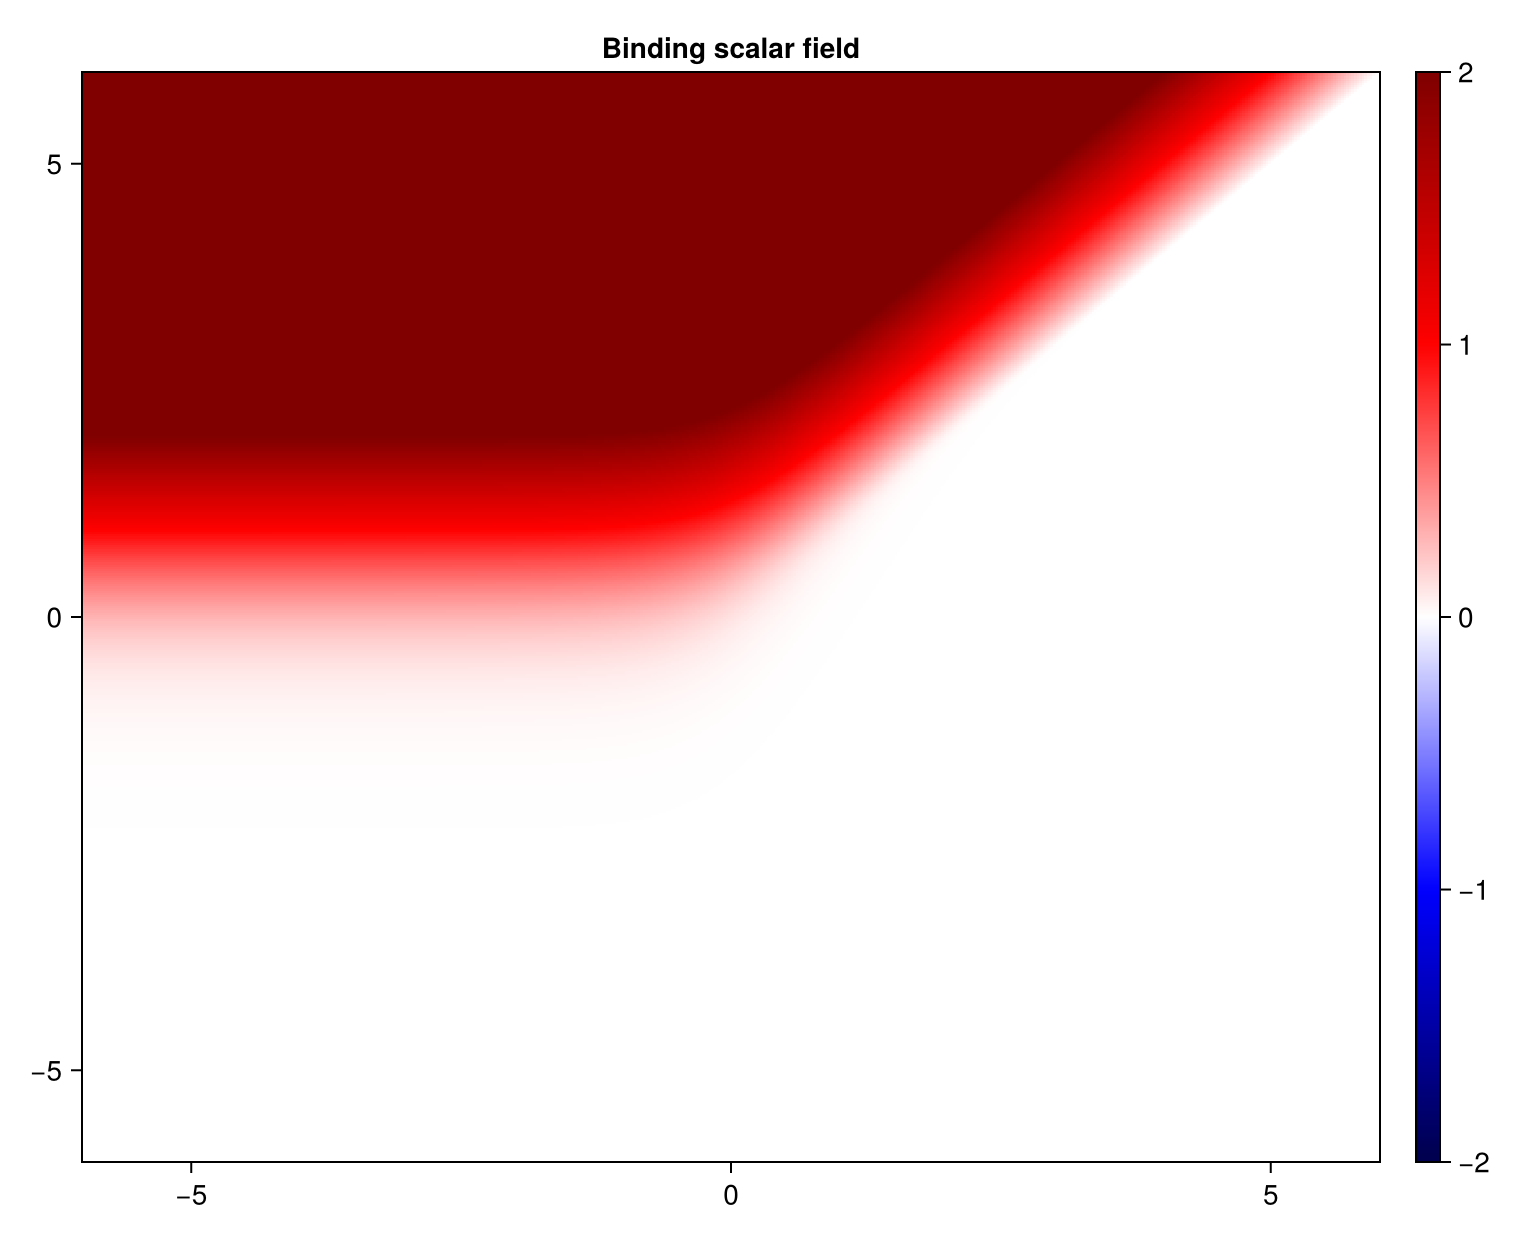

In [7]:
diff_mm_exact(logx, logqK) = let
    tE = exp10(logqK[1])
    tS = exp10(logqK[2])
    K = exp10(logqK[3])
    C_mm = log10(tE*tS/(K + tS))
    C = logx[3]
    clamp(C_mm - C, -2, 2)
end

mm_fixed = Dict(:K => 0.0)
mm_ranges = (-6, 6)

mm_fig, mm_ax, mm_data = plot_binding_regime_partition(
    mm_model;
    axes=[:tS, :tE],
    ranges=mm_ranges,
    fixed=mm_fixed,
    n=500,
    value_func=diff_mm_exact,
    colormap=:seismic,
    colorrange=(-2, 2),
)
mm_fig

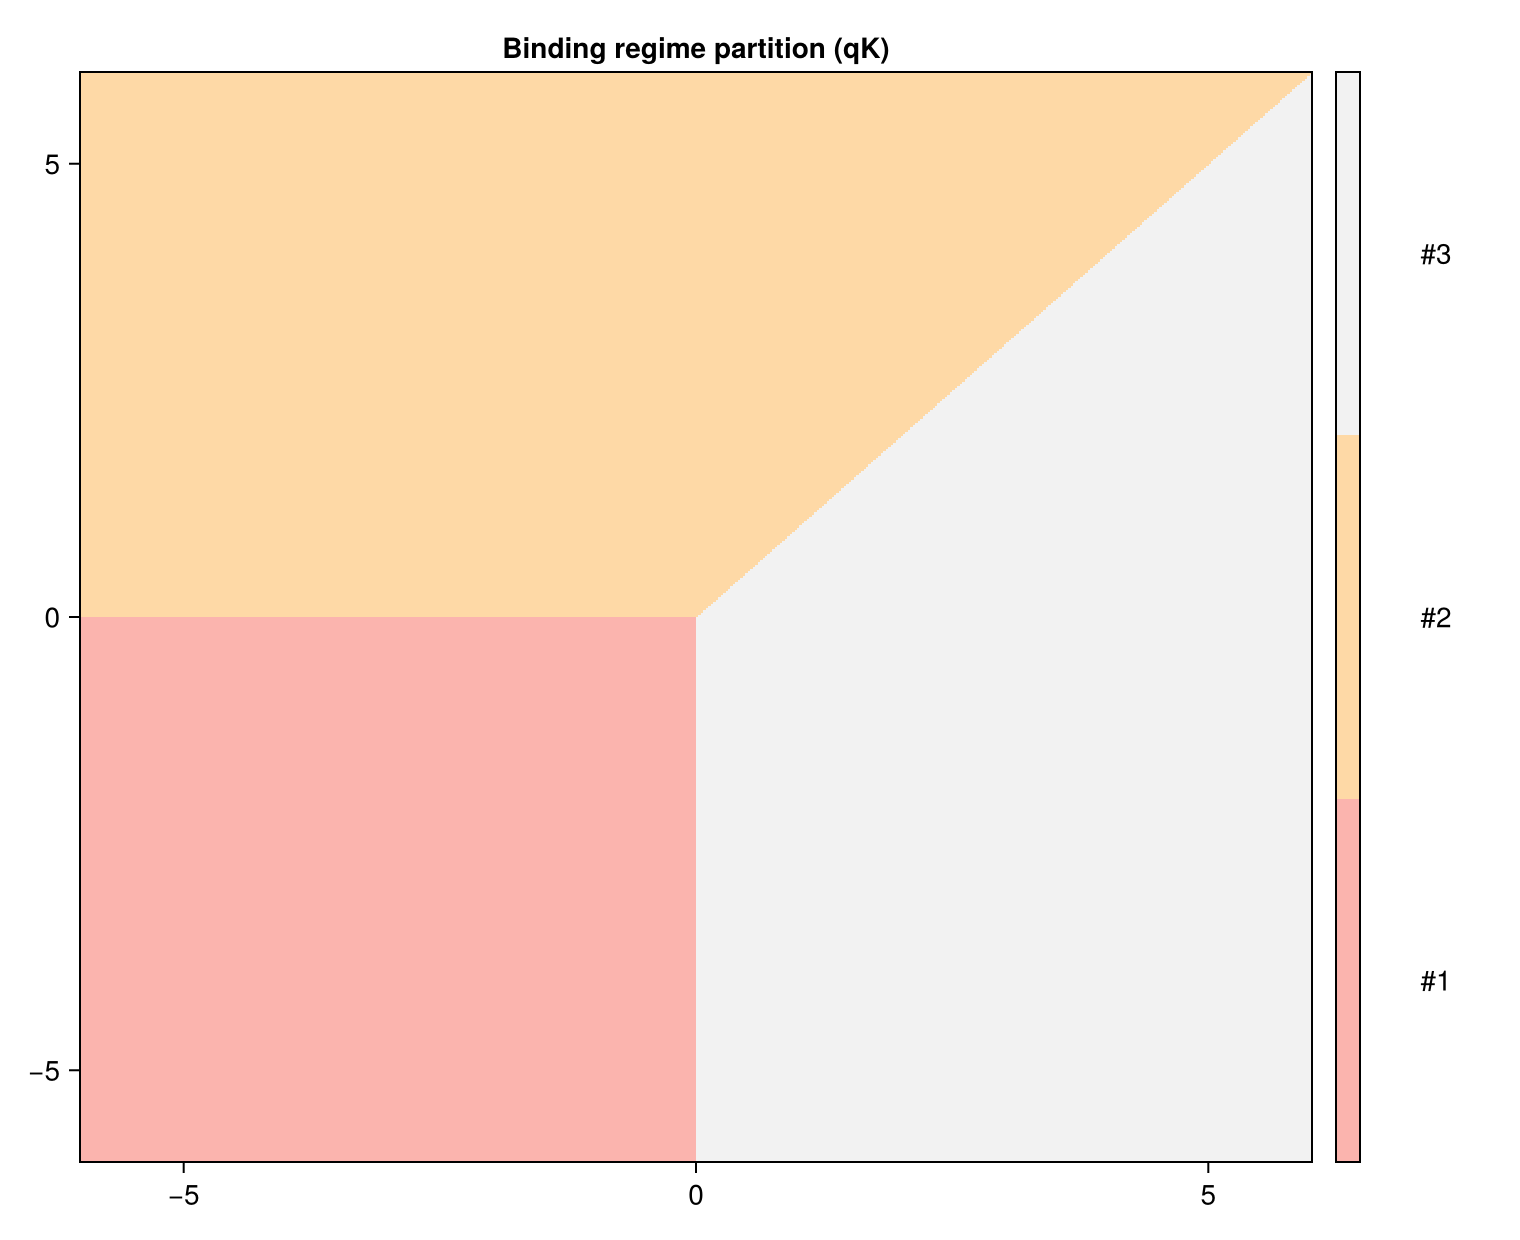

In [8]:
plot_binding_regime_partition(
    mm_model;
    axes=[:tS, :tE],
    ranges=mm_ranges,
    fixed=mm_fixed,
    n=500,
    chart=:qK,
)[1]

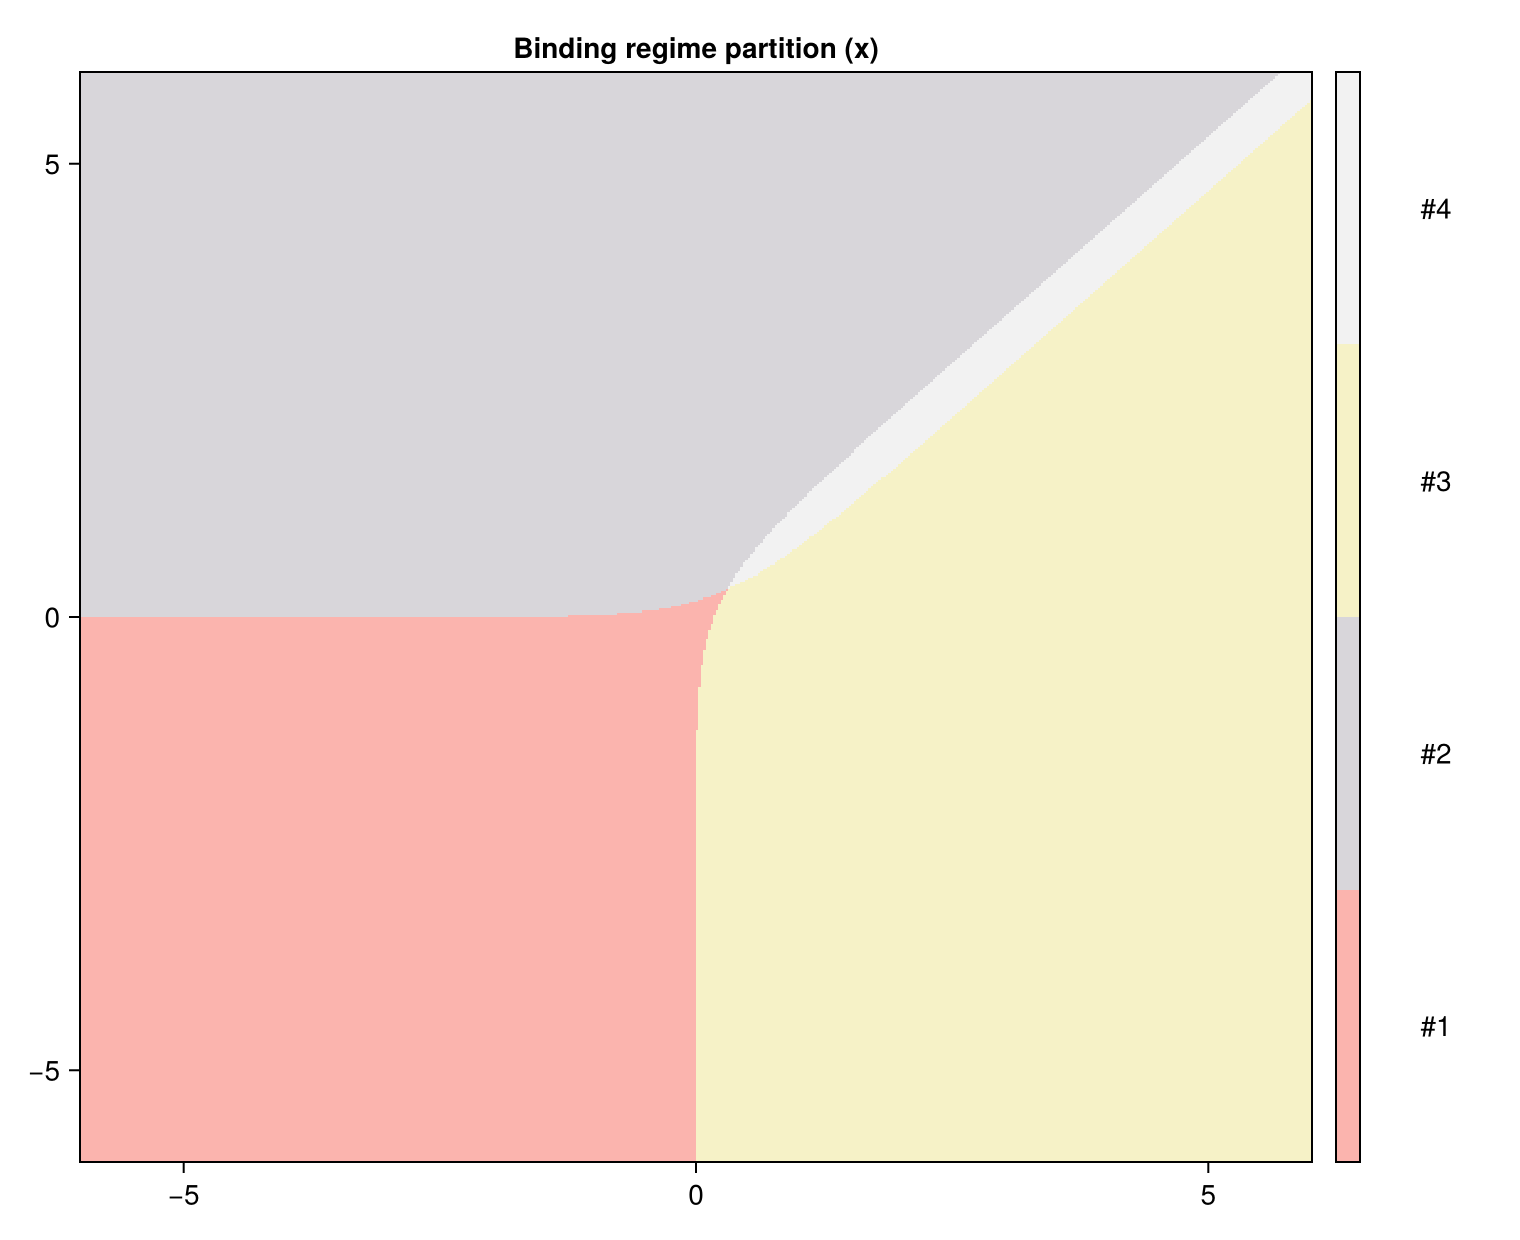

In [9]:
plot_binding_regime_partition(
    mm_model;
    axes=[:tS, :tE],
    ranges=mm_ranges,
    fixed=mm_fixed,
    n=500,
    chart=:x,
)[1]

## Two mechanisms for Hill-like behavior

The paper compares two `n = 2` mechanisms:

- `seq_2_model`: sequential binding, `E + S <-> C₁` and `C₁ + S <-> C₂`;
- `dimer_model`: dimer binding, `S + S <-> C_S` and `E + C_S <-> C₂`.

Both are tested against the Hill limiting expressions

```math
C_2 \sim q_E q_S^2/(K_1K_2),\qquad C_2 \sim q_E.
```

In [10]:
seq_2_model, dimer_model = let
    q_sym = [:qE, :qS]
    K_sym_seq = [:K₁, :K₂]
    K_sym_dimer = [:K_S, :K_E]
    x_sym_seq = [:E, :S, :C₁, :C₂]
    x_sym_dimer = [:E, :S, :C_S, :C₂]

    N_seq = [
        1 1 -1  0
        0 1  1 -1
    ]
    N_dimer = [
        0 2 -1  0
        1 0  1 -1
    ]

    Bnc(N=N_seq, x_sym=x_sym_seq, q_sym=q_sym, K_sym=K_sym_seq),
    Bnc(N=N_dimer, x_sym=x_sym_dimer, q_sym=q_sym, K_sym=K_sym_dimer)
end

find_all_regimes!(seq_2_model)
find_all_regimes!(dimer_model)

summary(seq_2_model)
summary(dimer_model)

[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 8 regimes found and 7 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...


----------Binding Network Summary:-------------
Number of species (n): 4
Number of conserved quantities (d): 2
Number of reactions (r): 2
L matrix: sparse([1, 2, 1, 2, 1, 2], [1, 2, 3, 3, 4, 4], [1, 1, 1, 1, 1, 2], 2, 4)
N matrix: sparse([1, 1, 2, 1, 2, 2], [1, 2, 2, 3, 3, 4], [1, 1, 1, -1, 1, -1], 2, 4)
Direction of binding reactions: forward
Catalysis involved: No
Regimes constructed: Yes
Number of regimes: 8
  - Invertible + Asymptotic: 5
  - Singular +  Asymptotic: 2
  - Invertible +  Non-Asymptotic: 1
  - Singular +  Non-Asymptotic: 0
-----------------------------------------------
----------Binding Network Summary:-------------
Number of species (n): 4
Number of conserved quantities (d): 2
Number of reactions (r): 2
L matrix: sparse([1, 2, 2, 1, 2], [1, 2, 3, 4, 4], [1, 1, 2, 1, 2], 2, 4)
N matrix: sparse([2, 1, 1, 2, 2], [1, 2, 3, 3, 4], [1, 2, -1, 1, -1], 2, 4)
Direction of binding reactions: forward
Catalysis involved: No
Regimes constructed: Yes
Number of regimes: 6
  - Inver

[ Info: 5.Calculating qK change directions on the regime graph...
[ Info: Finished.
[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 6 regimes found and 6 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...
[ Info: 5.Calculating qK change directions on the regime graph...
[ Info: Finished.


### Sequential `n = 2`: conservation and equilibrium

In [11]:
show_conservation(seq_2_model), show_equilibrium(seq_2_model)

(Symbolics.Equation[qE ~ C₁ + C₂ + E, qS ~ C₁ + 2C₂ + S], Symbolics.Equation[K₁ ~ (E*S) / C₁, K₂ ~ (C₁*S) / C₂])

### Sequential `n = 2`: non-singular `C₂` expressions

The Hill criterion captures only the low-substrate source regime `(E,S)` and the saturated high-substrate regime `(C₂,S)`.  Other non-singular regimes have different reaction-order expressions, so a Hill function does not describe them.

In [13]:
seq_2_C2_expressions = output_expression_table(seq_2_model; output=:C₂)
seq_2_hill_regimes = find_Hill_regimes(seq_2_model; output=:C₂)

seq_2_C2_expressions

6-element Vector{@NamedTuple{idx::Int64, perm::Vector{Int64}, expression::Symbolics.Equation, hill_branch::Symbol}}:
 (idx = 1, perm = [1, 2], expression = C₂ ~ (qE*(qS^(2//1))) / (K₁*K₂), hill_branch = :hill_low_substrate)
 (idx = 2, perm = [1, 3], expression = C₂ ~ (K₁*(qS^(2//1))) / (K₂*qE), hill_branch = :not_captured)
 (idx = 3, perm = [1, 4], expression = C₂ ~ (1//2)*qS, hill_branch = :not_captured)
 (idx = 4, perm = [3, 2], expression = C₂ ~ (qE*qS) / K₂, hill_branch = :not_captured)
 (idx = 6, perm = [3, 4], expression = C₂ ~ (1//2)*qS, hill_branch = :not_captured)
 (idx = 7, perm = [4, 2], expression = C₂ ~ qE, hill_branch = :saturated_high_substrate)

In [14]:
seq_2_hill_regimes

2-element Vector{NamedTuple}:
 (idx = 1, perm = [1, 2], branch = :hill_low_substrate, exponents = Rational{Int64}[1, 2, -1, -1], expression = C₂ ~ (qE*(qS^(2//1))) / (K₁*K₂))
 (idx = 7, perm = [4, 2], branch = :saturated_high_substrate, exponents = Rational{Int64}[1, 0, 0, 0], expression = C₂ ~ qE)

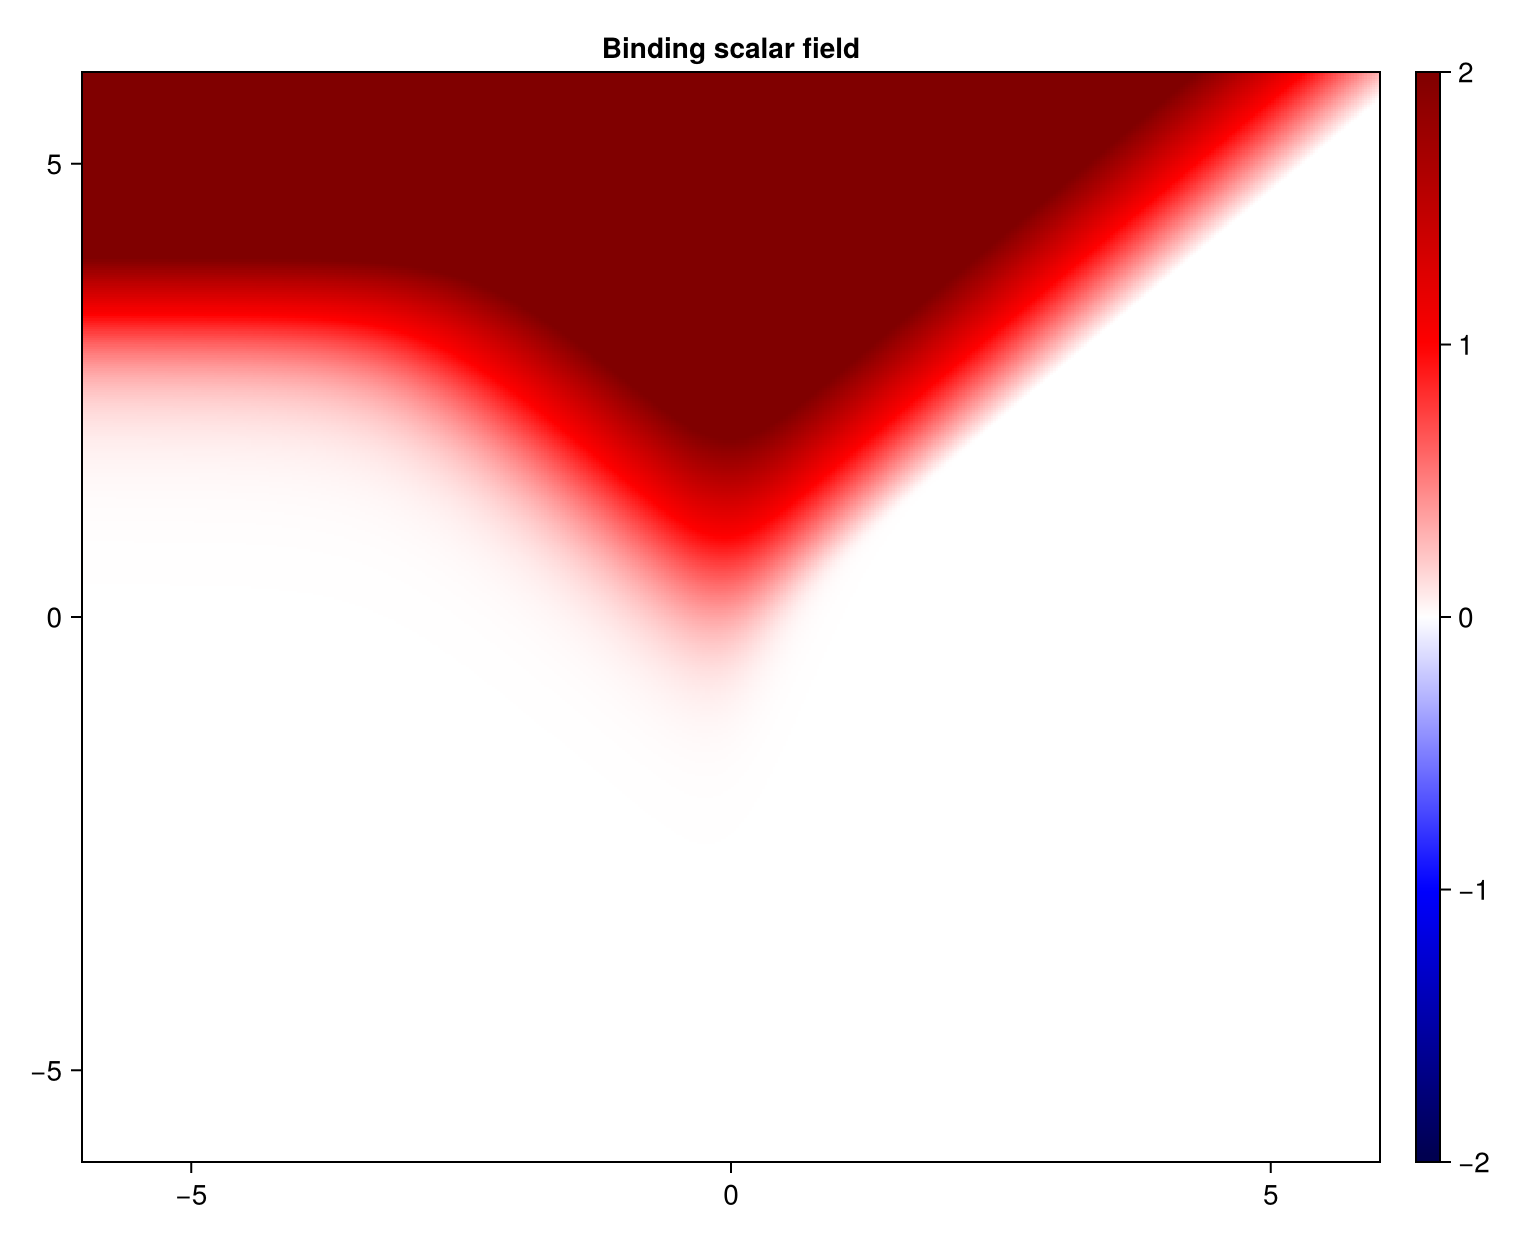

In [15]:
diff_seq_2_hill_exact(logx, logqK) = let
    qE = exp10(logqK[1])
    qS = exp10(logqK[2])
    K_1 = exp10(logqK[3])
    K_2 = exp10(logqK[4])
    C2_hill = log10(qE*qS^2/(K_1*K_2 + qS^2))
    C2 = logx[4]
    clamp(C2_hill - C2, -2, 2)
end

seq_2_fixed = Dict(:K₂ => -3, :K₁ => 3)
seq_2_ranges = (-6, 6)

seq_2_fig, seq_2_ax, seq_2_data = plot_binding_regime_partition(
    seq_2_model;
    axes=[:qS, :qE],
    ranges=seq_2_ranges,
    fixed=seq_2_fixed,
    n=500,
    value_func=diff_seq_2_hill_exact,
    colormap=:seismic,
    colorrange=(-2, 2),
)
seq_2_fig

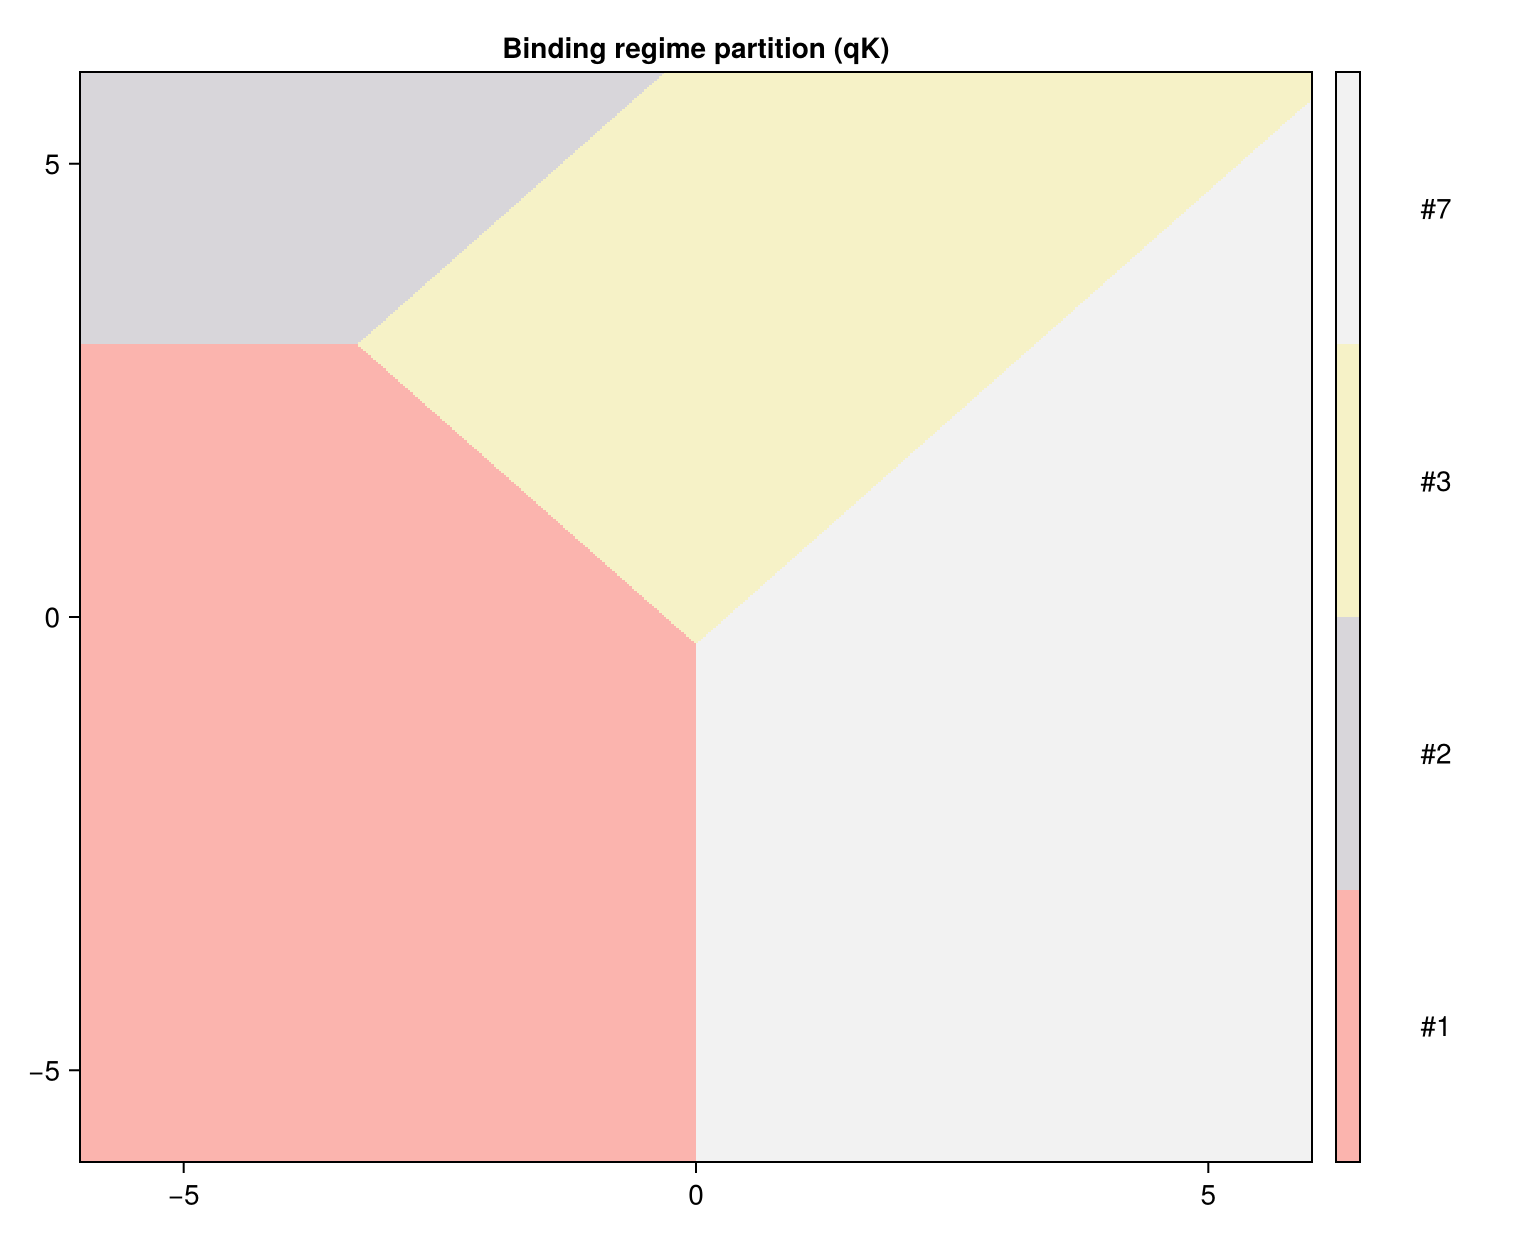

In [ ]:
plot_binding_regime_partition(
    seq_2_model;
    axes=[:qS, :qE],
    ranges=seq_2_ranges,
    fixed=seq_2_fixed,
    n=500,
    chart=:qK,
)[1]

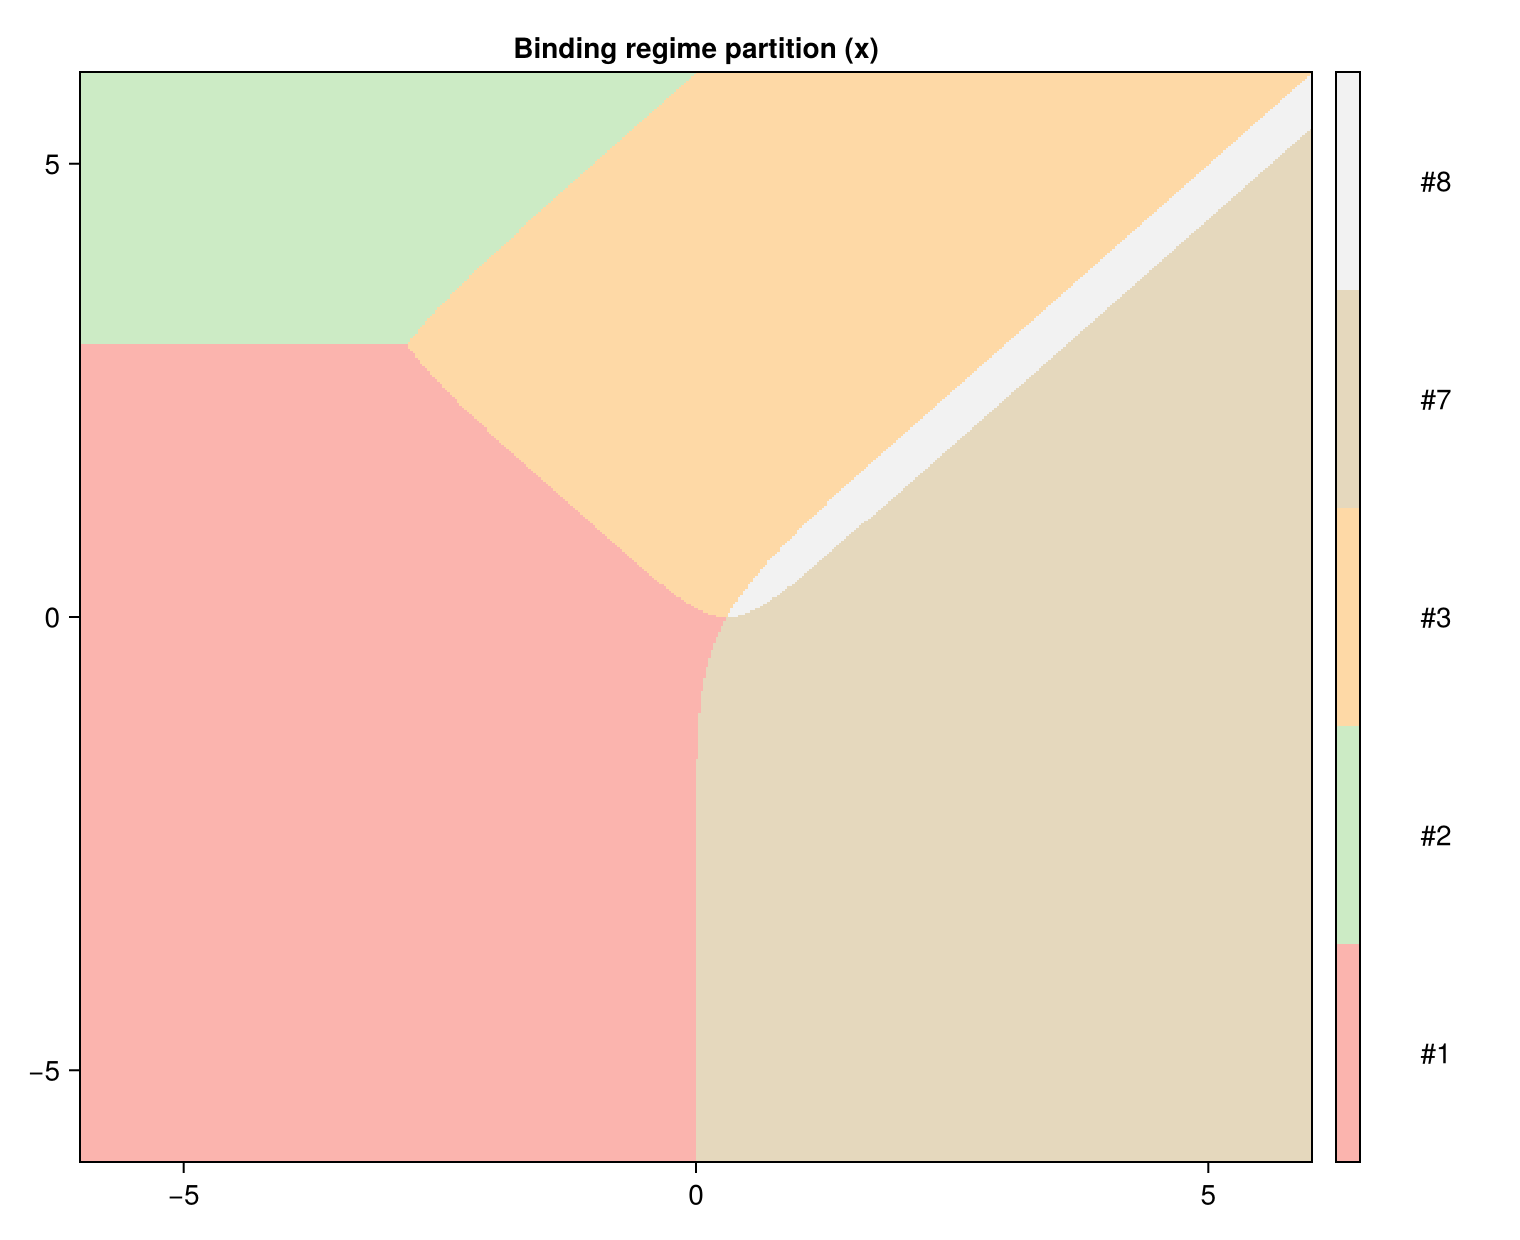

In [18]:
plot_binding_regime_partition(
    seq_2_model;
    axes=[:qS, :qE],
    ranges=seq_2_ranges,
    fixed=seq_2_fixed,
    n=500,
    chart=:x,
)[1]

### Dimer `n = 2`: conservation and equilibrium

In [19]:
show_conservation(dimer_model), show_equilibrium(dimer_model)

(Symbolics.Equation[qE ~ C₂ + E, qS ~ 2C_S + 2C₂ + S], Symbolics.Equation[K_S ~ (S^2) / C_S, K_E ~ (C_S*E) / C₂])

### Dimer `n = 2`: non-singular `C₂` expressions

The Hill criterion captures `(E,S)` as the low-substrate source regime.  It also captures two saturated regimes, `(C₂,S)` and `(C₂,C_S)`, because both reduce to `C₂ ~ qE`.

In [21]:
dimer_C2_expressions = output_expression_table(dimer_model; output=:C₂)
dimer_hill_regimes = find_Hill_regimes(dimer_model; output=:C₂)

dimer_C2_expressions

5-element Vector{@NamedTuple{idx::Int64, perm::Vector{Int64}, expression::Symbolics.Equation, hill_branch::Symbol}}:
 (idx = 1, perm = [1, 2], expression = C₂ ~ (qE*(qS^(2//1))) / (K_E*K_S), hill_branch = :hill_low_substrate)
 (idx = 2, perm = [4, 2], expression = C₂ ~ qE, hill_branch = :saturated_high_substrate)
 (idx = 3, perm = [1, 3], expression = C₂ ~ ((1//2)*qE*qS) / K_E, hill_branch = :not_captured)
 (idx = 4, perm = [4, 3], expression = C₂ ~ qE, hill_branch = :saturated_high_substrate)
 (idx = 5, perm = [1, 4], expression = C₂ ~ (1//2)*qS, hill_branch = :not_captured)

In [22]:
dimer_hill_regimes

3-element Vector{NamedTuple}:
 (idx = 1, perm = [1, 2], branch = :hill_low_substrate, exponents = Rational{Int64}[1, 2, -1, -1], expression = C₂ ~ (qE*(qS^(2//1))) / (K_E*K_S))
 (idx = 2, perm = [4, 2], branch = :saturated_high_substrate, exponents = Rational{Int64}[1, 0, 0, 0], expression = C₂ ~ qE)
 (idx = 4, perm = [4, 3], branch = :saturated_high_substrate, exponents = Rational{Int64}[1, 0, 0, 0], expression = C₂ ~ qE)

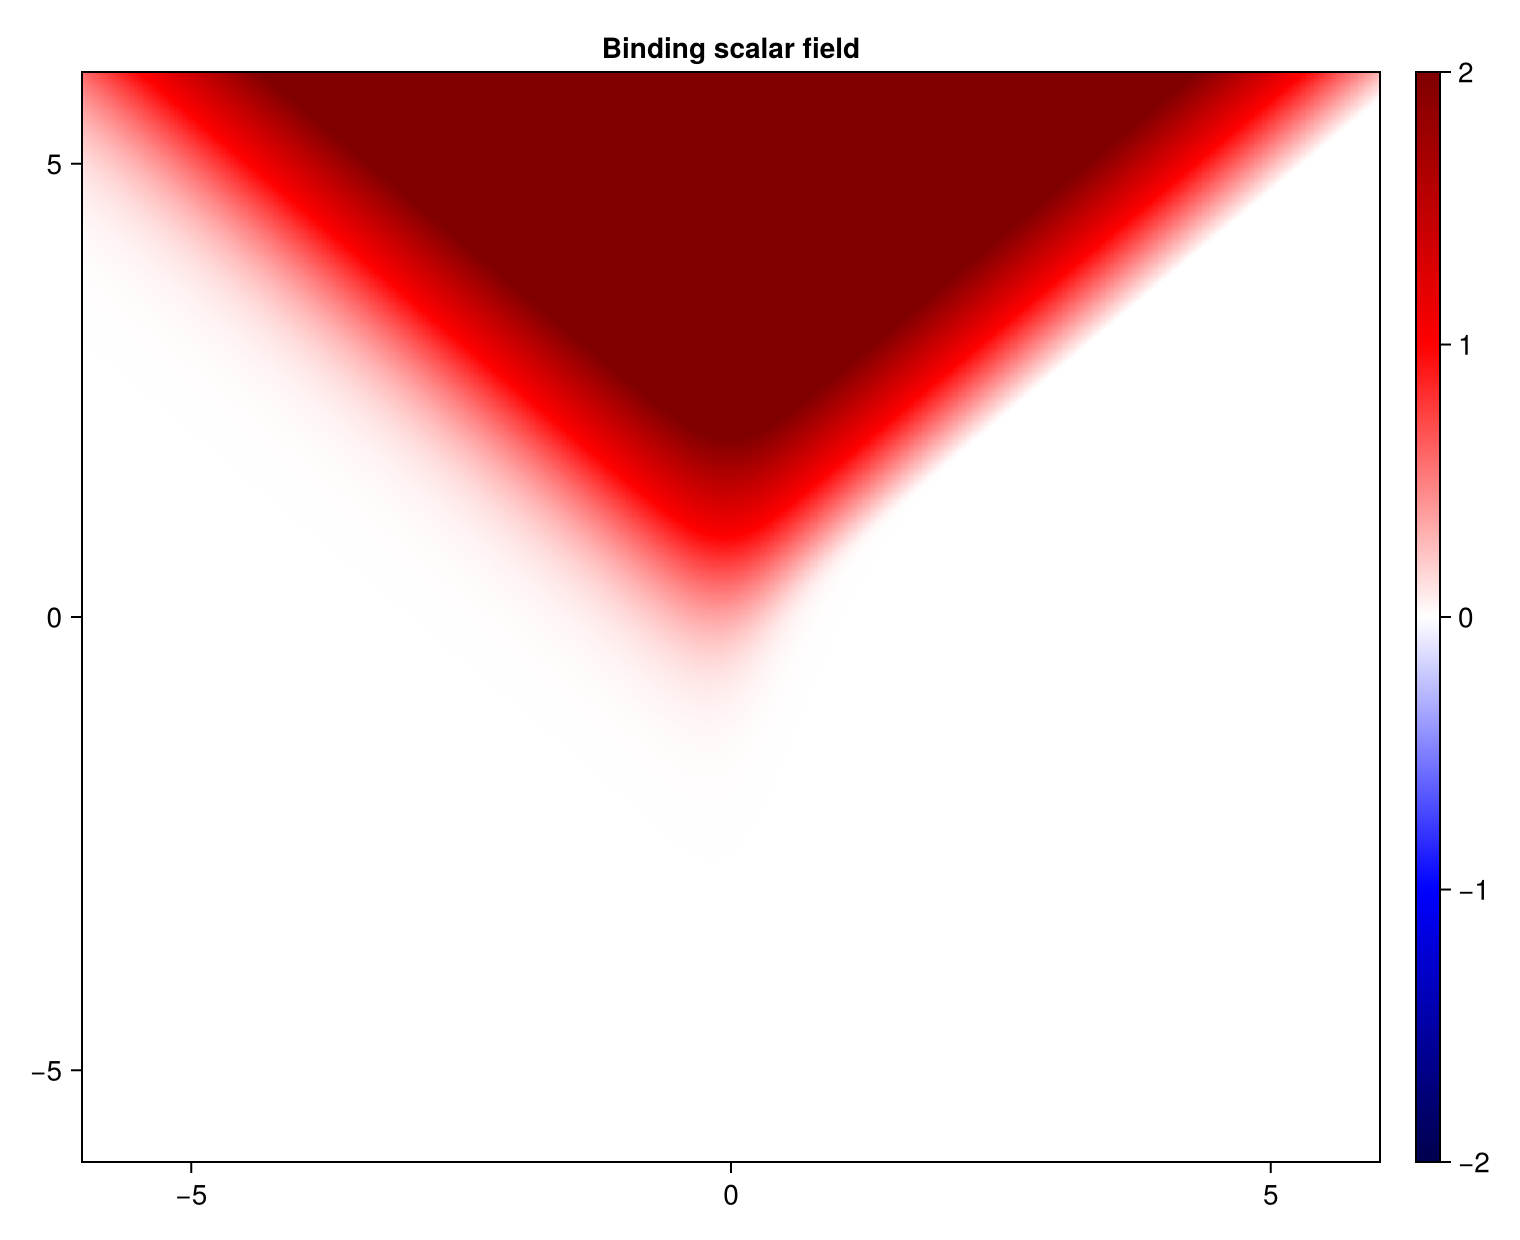

In [23]:
diff_dimer_hill_exact(logx, logqK) = let
    qE = exp10(logqK[1])
    qS = exp10(logqK[2])
    K_S = exp10(logqK[3])
    K_E = exp10(logqK[4])
    C2_hill = log10(qE*qS^2/(K_S*K_E + qS^2))
    C2 = logx[4]
    clamp(C2_hill - C2, -2, 2)
end

dimer_fixed = Dict(:K_S => 3, :K_E => -3)
dimer_ranges = (-6, 6)

dimer_fig, dimer_ax, dimer_data = plot_binding_regime_partition(
    dimer_model;
    axes=[:qS, :qE],
    ranges=dimer_ranges,
    fixed=dimer_fixed,
    n=500,
    value_func=diff_dimer_hill_exact,
    colormap=:seismic,
    colorrange=(-2, 2),
)
dimer_fig

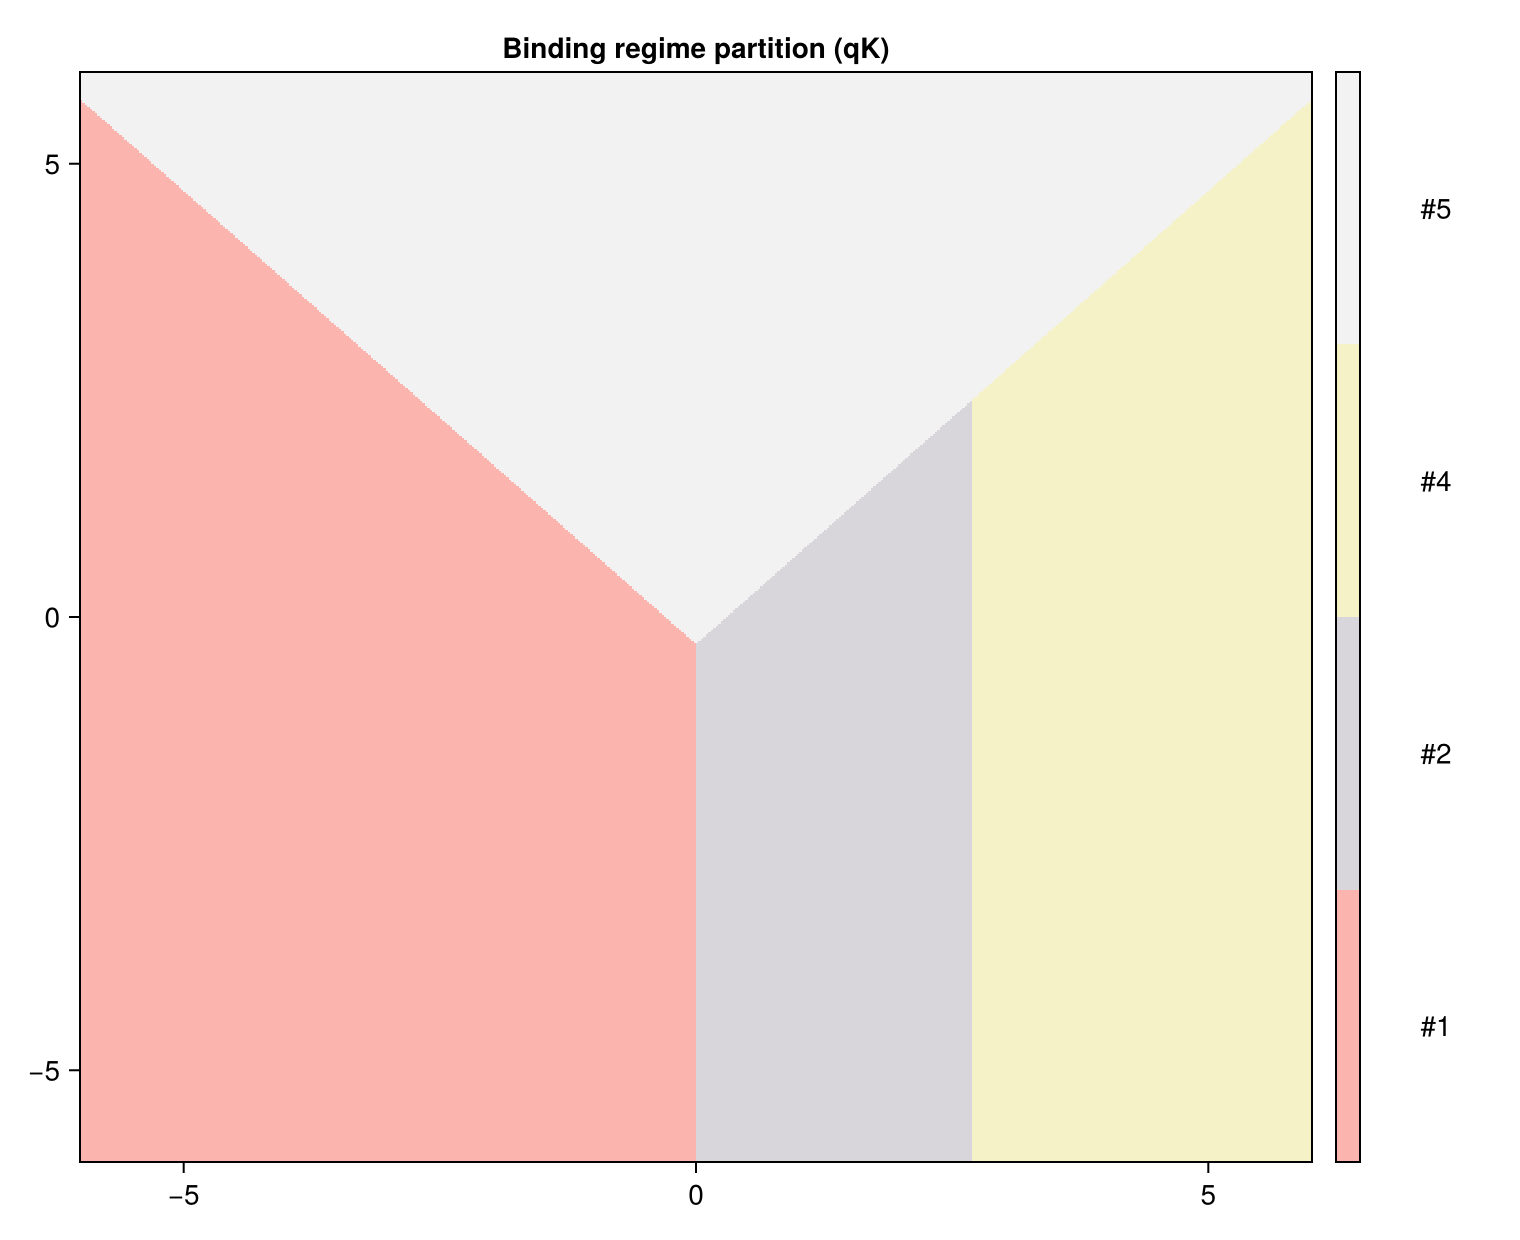

In [25]:
plot_binding_regime_partition(
    dimer_model;
    axes=[:qS, :qE],
    ranges=dimer_ranges,
    fixed=dimer_fixed,
    n=500,
    chart=:qK,
)[1]

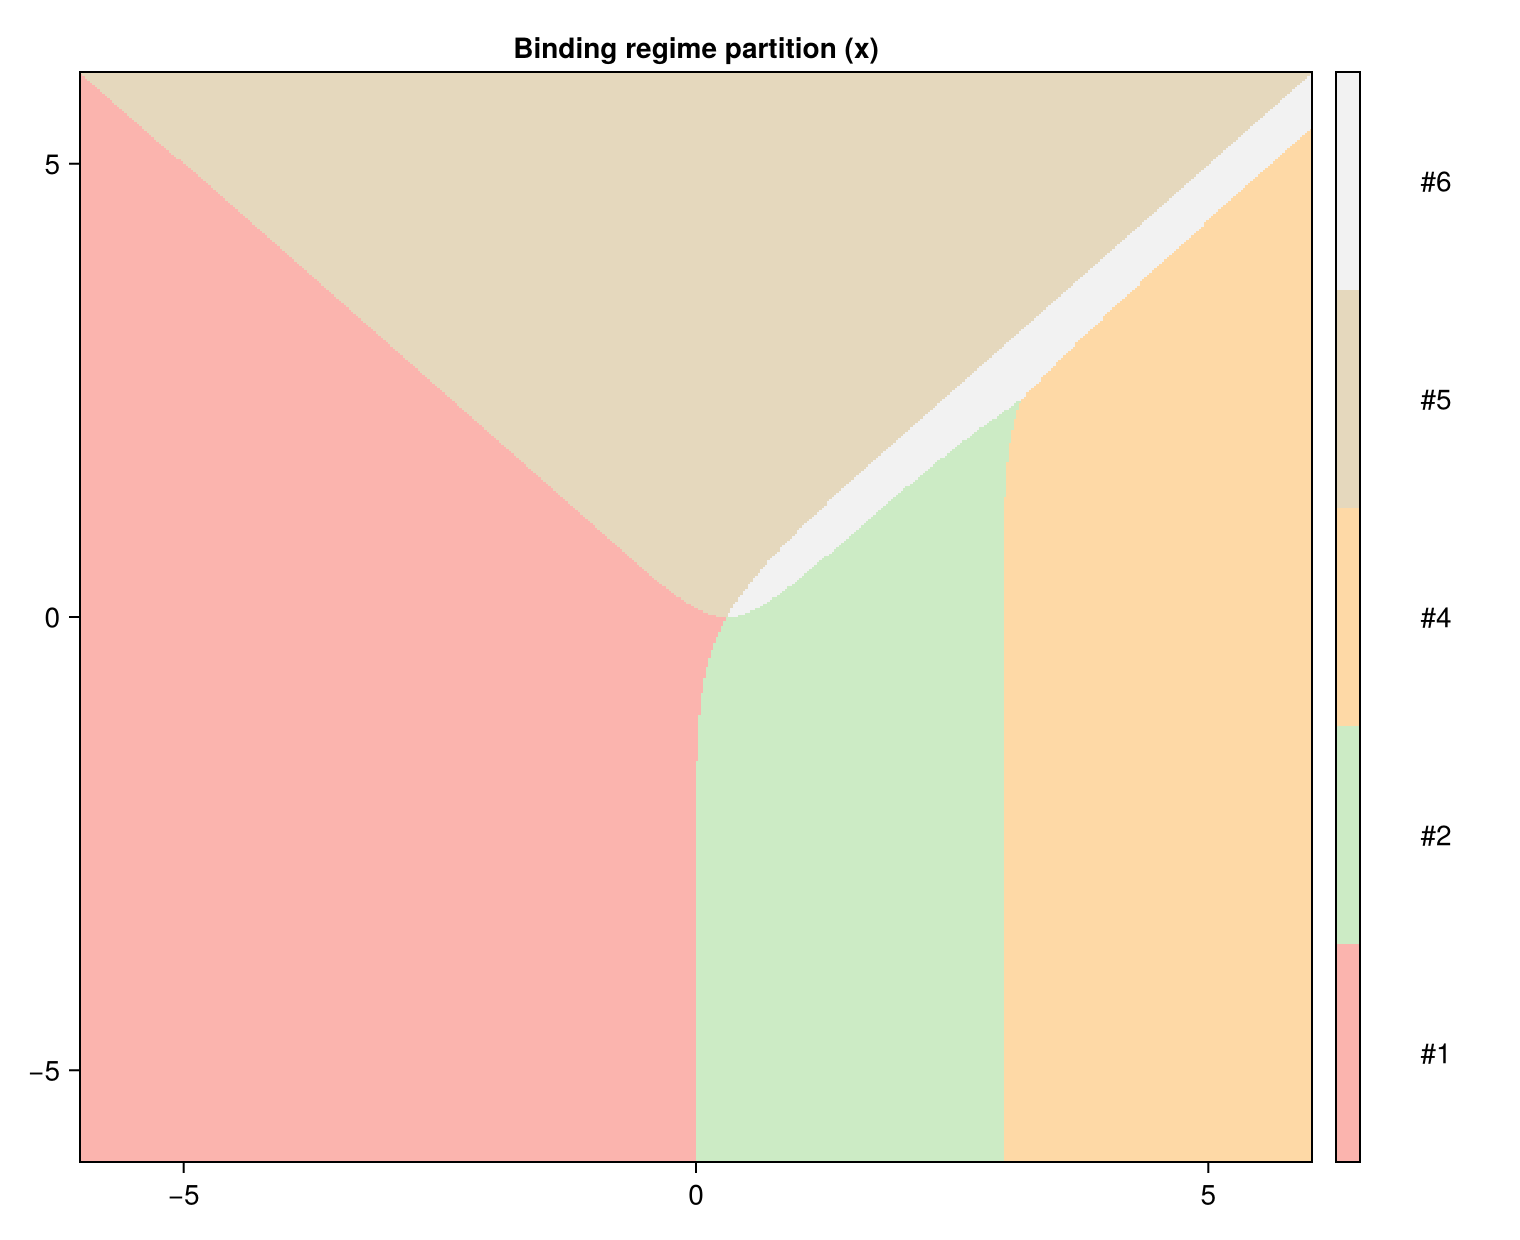

In [26]:
plot_binding_regime_partition(
    dimer_model;
    axes=[:qS, :qE],
    ranges=dimer_ranges,
    fixed=dimer_fixed,
    n=500,
    chart=:x,
)[1]

## Sequential Hill functions for general `n`

The original working notebook stored two arrays named `r_idx` and `Val_hill`.  Here they are computed directly and renamed according to the control scenario:

- `R_control_with_tE`: `tS` is treated as the free swept input, so the source/sink intersection is projected by eliminating the `tS` coordinate;
- `R_control_with_tE_tS`: both `tE` and `tS` are treated as controlled parameters, so the source and sink regime volumes are summed in the full parameter space.

The source and sink regimes are the generic sequential Hill regimes `(S,E)` and `(S,Cn)`, represented by permutations `[1,2]` and `[1,n+2]`.

In [27]:
function sequential_hill_N(hill_n)
    N = zeros(Int, hill_n, hill_n + 2)
    N[:, 1] .= 1
    for i in 1:hill_n
        N[i, i + 1] = 1
        N[i, i + 2] = -1
    end
    return N
end

function sequential_hill_n_model(hill_n)
    x_syms = vcat([:S, :E], Symbol.("C" .* string.(1:hill_n)))
    K_syms = Symbol.("K" .* string.(1:hill_n))
    Bnc(N=sequential_hill_N(hill_n), x_sym=x_syms, q_sym=[:tS, :tE], K_sym=K_syms)
end

function hill_control_rindices(hill_n; rel_tol=DEFAULT_REL_TOL, time_limit=DEFAULT_TIME_LIMIT)
    model = sequential_hill_n_model(hill_n)
    source_perm = [1, 2]
    sink_perm = [1, hill_n + 2]

    source_poly = regime_polyhedron_from_perm(model, source_perm)
    sink_poly = regime_polyhedron_from_perm(model, sink_perm)

    R_control_with_tE_tS_parts = calc_volume(
        [source_poly, sink_poly];
        rel_tol,
        time_limit,
        asymptotic=true,
    )

    free_tS_poly = intersect(source_poly, sink_poly)
    free_tS_poly = eliminate_coordinate(free_tS_poly, locate_sym_qK(model, :tS))
    R_control_with_tE = calc_volume(
        free_tS_poly;
        rel_tol,
        time_limit,
        asymptotic=true,
    )

    return (;
        n=hill_n,
        model,
        source_perm,
        sink_perm,
        R_control_with_tE,
        R_control_with_tE_tS_parts,
        R_control_with_tE_tS=sum(volume_mean, R_control_with_tE_tS_parts),
    )
end

hill_control_rindices (generic function with 1 method)

In [28]:
hill_n_range = 1:13
hill_rindex_results = [hill_control_rindices(n) for n in hill_n_range]

R_control_with_tE = [r.R_control_with_tE for r in hill_rindex_results]
R_control_with_tE_tS_parts = [r.R_control_with_tE_tS_parts for r in hill_rindex_results]
R_control_with_tE_tS = [r.R_control_with_tE_tS for r in hill_rindex_results]

hill_rindex_table = [
    (;
        n=r.n,
        R_control_with_tE=volume_summary(r.R_control_with_tE),
        R_control_with_tE_tS=round(r.R_control_with_tE_tS, digits=4),
        source_volume=volume_summary(r.R_control_with_tE_tS_parts[1]),
        sink_volume=volume_summary(r.R_control_with_tE_tS_parts[2]),
    )
    for r in hill_rindex_results
]

hill_rindex_table

[ Info: Number of polyhedra to calc volume: 2
[ Info: All regimes converged after 7700000 samples.
[ Info: Number of polyhedra to calc volume: 1
[ Info: All regimes converged after 3900000 samples.
[ Info: Number of polyhedra to calc volume: 2
[ Info: All regimes converged after 10800000 samples.
[ Info: Number of polyhedra to calc volume: 1
[ Info: All regimes converged after 11600000 samples.
[ Info: Number of polyhedra to calc volume: 2
[ Info: All regimes converged after 12500000 samples.
[ Info: Number of polyhedra to calc volume: 1
[ Info: All regimes converged after 19300000 samples.
[ Info: Number of polyhedra to calc volume: 2
[ Info: All regimes converged after 13600000 samples.
[ Info: Number of polyhedra to calc volume: 1
[ Info: All regimes converged after 27000000 samples.
[ Info: Number of polyhedra to calc volume: 2
[ Info: All regimes converged after 14300000 samples.
[ Info: Number of polyhedra to calc volume: 1
[ Info: All regimes converged after 34600000 samples.
[ 

13-element Vector{@NamedTuple{n::Int64, R_control_with_tE::@NamedTuple{mean::Float64, stderr::Float64}, R_control_with_tE_tS::Float64, source_volume::@NamedTuple{mean::Float64, stderr::Float64}, sink_volume::@NamedTuple{mean::Float64, stderr::Float64}}}:
 (n = 1, R_control_with_tE = (mean = 0.5002, stderr = 0.0005), R_control_with_tE_tS = 0.6668, source_volume = (mean = 0.3332, stderr = 0.0003), sink_volume = (mean = 0.3336, stderr = 0.0003))
 (n = 2, R_control_with_tE = (mean = 0.2501, stderr = 0.0002), R_control_with_tE_tS = 0.5625, source_volume = (mean = 0.2636, stderr = 0.0003), sink_volume = (mean = 0.2989, stderr = 0.0003))
 (n = 3, R_control_with_tE = (mean = 0.1665, stderr = 0.0002), R_control_with_tE_tS = 0.5201, source_volume = (mean = 0.236, stderr = 0.0002), sink_volume = (mean = 0.2841, stderr = 0.0003))
 (n = 4, R_control_with_tE = (mean = 0.1249, stderr = 0.0001), R_control_with_tE_tS = 0.4971, source_volume = (mean = 0.2214, stderr = 0.0002), sink_volume = (mean = 0.27

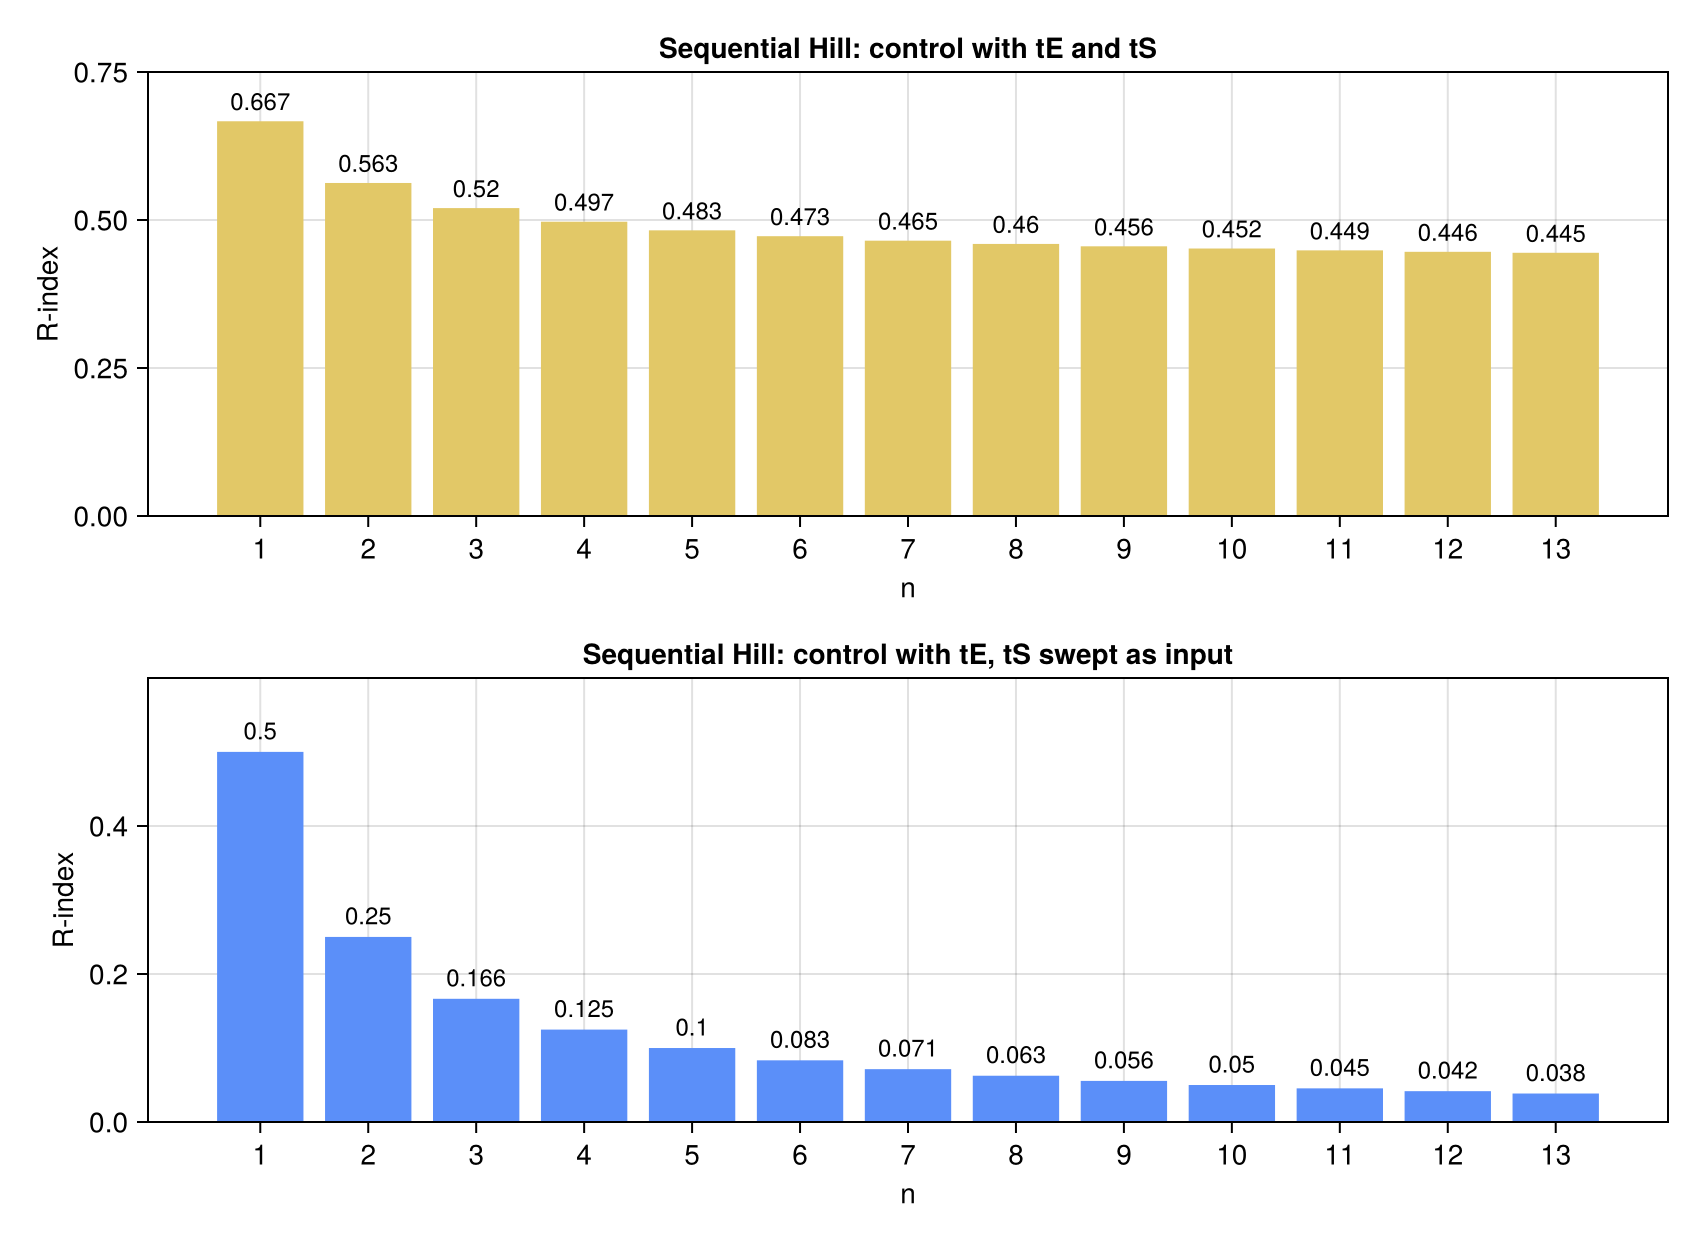

In [29]:
let
    ns = collect(hill_n_range)
    fig = Figure(size=(850, 620), backgroundcolor=:white)

    ax1 = Axis(
        fig[1, 1];
        xlabel="n",
        ylabel="R-index",
        xticks=ns,
        title="Sequential Hill: control with tE and tS",
    )
    barplot!(ax1, ns, R_control_with_tE_tS; color="#E2C867")
    text!(ax1, ns, R_control_with_tE_tS .+ 0.01; text=string.(round.(R_control_with_tE_tS, digits=3)), align=(:center, :bottom), fontsize=12)
    ylims!(ax1, 0, 0.75)

    ax2 = Axis(
        fig[2, 1];
        xlabel="n",
        ylabel="R-index",
        xticks=ns,
        title="Sequential Hill: control with tE, tS swept as input",
    )
    R_tE_values = volume_mean.(R_control_with_tE)
    barplot!(ax2, ns, R_tE_values; color="#5B8FF9")
    text!(ax2, ns, R_tE_values .+ 0.01; text=string.(round.(R_tE_values, digits=3)), align=(:center, :bottom), fontsize=12)
    ylims!(ax2, 0, 0.60)

    fig
end